# From 4-4 to Champions: A Basketball Analytics Case Study

**How Data-Driven Coaching Led the Longshots to an ABA Championship**

**Author:** Paa Yaw Fuachie-Sobreh

**Date:** April 2026

**Tools:** Python, pandas, NumPy, scikit-learn, SciPy, matplotlib, seaborn

---

## Abstract

This project documents the analytics workflow behind coaching the Longshots basketball team to the 2025-26 Ashesi Basketball Association (ABA) championship. Starting with a .500 regular season record (4W-4L), I used statistical analysis to identify exploitable patterns, build opponent scouting reports, and develop data-backed game plans. The team swept both playoff series (2-0 vs Los Ashtros, 3-0 vs AshKnights), winning five consecutive games to claim the title.

The analysis follows the actual chronological arc of the season. Association analysis was developed during the semifinal series. Regression modeling was introduced before the finals. Every coaching decision was informed by the data presented here.

## Context

The ABA is a five-team university league at Ashesi University, Ghana. The 2025-26 season had 20 regular season games (8 per team), followed by best-of-three semifinals and best-of-five finals. Regular season games use two 20-minute halves. Playoffs use four 12-minute quarters.

---
## 1. Data Collection and Cleaning

The dataset contains player-level box scores for all 28 games (20 regular season + 8 playoff), compiled from official stat sheets.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

import shutil
shutil.copy('/content/drive/My Drive/long/ashesi_basketball_2025_26_full.csv', '/content/ashesi_basketball_2025_26_full.csv')

df = pd.read_csv('/content/ashesi_basketball_2025_26_full.csv')
print(f'Dataset: {len(df)} rows, {len(df.columns)} columns')
print(f'Games: {df["game_number"].nunique()}')
print(f'Teams: {sorted(df["team"].unique())}')
print(f'\nGame types:')
print(df.drop_duplicates('game_number')['game_type'].value_counts())

Dataset: 396 rows, 31 columns
Games: 28
Teams: ['AshKnights', 'Berekusu Warriors', 'HillBlazers', 'Longshots', 'Los Ashtros']

Game types:
game_type
Regular Season              19
Playoff - Semifinal          5
Playoff - Finals             3
Regular Season (Forfeit)     1
Name: count, dtype: int64


In [6]:
forfeit_mask = df['game_type'].str.contains('Forfeit', na=False)
df_clean = df[~forfeit_mask].copy()
df_reg = df_clean[df_clean['game_type'] == 'Regular Season'].copy()
df_playoff = df_clean[df_clean['game_type'].str.contains('Playoff', na=False)].copy()

print(f'Removed {forfeit_mask.sum()} forfeit rows')
print(f'Regular season: {df_reg["game_number"].nunique()} games, {len(df_reg)} rows')
print(f'Playoffs: {df_playoff["game_number"].nunique()} games, {len(df_playoff)} rows')

Removed 2 forfeit rows
Regular season: 19 games, 273 rows
Playoffs: 8 games, 121 rows


---
## 2. League Overview

Before diving into team-specific analysis, we examine the competitive landscape using both traditional stats and offensive/defensive ratings.

**Offensive Rating (ORTG)** = points scored per 100 possessions. **Defensive Rating (DRTG)** = points allowed per 100 possessions. Possessions are estimated as FGA + 0.44 * FTA (standard approximation when turnover data is unavailable).

In [7]:
reg_games = df_reg.drop_duplicates(['game_number', 'team'])[
    ['game_number', 'team', 'opponent', 'team_score', 'opponent_score', 'game_outcome']
]

standings = reg_games.groupby('team').agg(
    W=('game_outcome', lambda x: (x == 'Won').sum()),
    L=('game_outcome', lambda x: (x == 'Lost').sum()),
    PPG=('team_score', 'mean'),
    Opp_PPG=('opponent_score', 'mean'),
).reset_index()
standings['Margin'] = (standings['PPG'] - standings['Opp_PPG']).round(1)
standings = standings.sort_values('W', ascending=False)

print('2025-26 ABA Regular Season Standings')
print('=' * 55)
print(standings.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

2025-26 ABA Regular Season Standings
             team  W  L  PPG  Opp_PPG  Margin
       AshKnights  6  2 61.6     54.8     6.9
      Los Ashtros  5  2 52.1     49.4     2.7
        Longshots  4  4 52.2     54.8    -2.5
      HillBlazers  2  5 56.7     61.3    -4.6
Berekusu Warriors  2  6 52.4     55.1    -2.8


In [8]:
team_game = df_reg.groupby(
    ['game_number', 'team', 'opponent', 'team_score', 'opponent_score', 'game_outcome']
).agg(
    fga=('fga', 'sum'), fta=('fta', 'sum'), fgm=('fgm', 'sum'),
    three_pm=('three_pm', 'sum'), three_pa=('three_pa', 'sum'),
    reb=('reb', 'sum'), ast=('ast', 'sum'), stl=('stl', 'sum'),
).reset_index()

team_game['poss'] = team_game['fga'] + 0.44 * team_game['fta']
team_game['ortg'] = team_game['team_score'] / team_game['poss'] * 100
team_game['drtg'] = team_game['opponent_score'] / team_game['poss'] * 100
team_game['net_rtg'] = team_game['ortg'] - team_game['drtg']

ratings = team_game.groupby('team').agg(
    ORTG=('ortg', 'mean'), DRTG=('drtg', 'mean'),
    NET=('net_rtg', 'mean'), PACE=('poss', 'mean'),
).round(1).sort_values('NET', ascending=False)

print('\nOffensive & Defensive Ratings (per 100 possessions)')
print('=' * 60)
print(ratings.to_string())


Offensive & Defensive Ratings (per 100 possessions)
                   ORTG  DRTG  NET  PACE
team                                    
AshKnights         88.5  79.8  8.7  70.8
Los Ashtros        79.9  75.7  4.2  66.4
Longshots          79.1  81.2 -2.0  67.4
Berekusu Warriors  82.0  86.0 -4.0  64.2
HillBlazers        86.8  93.6 -6.8  65.5


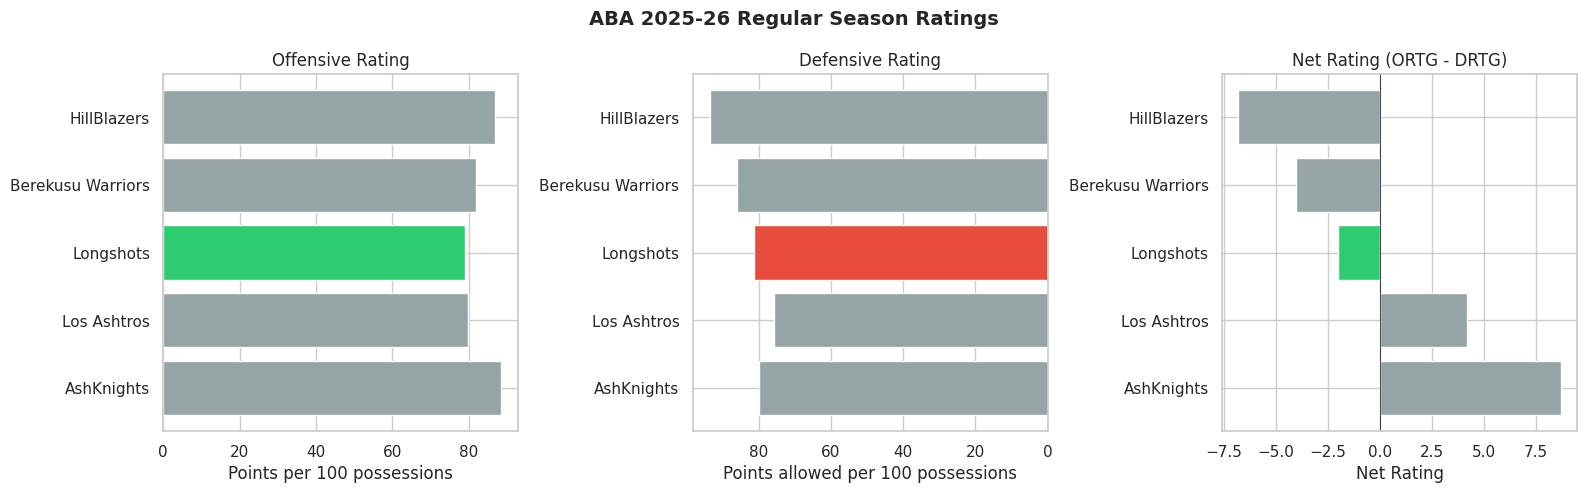

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

teams = ratings.index.values
hl = ['#2ecc71' if t == 'Longshots' else '#95a5a6' for t in teams]

axes[0].barh(teams, ratings['ORTG'].values, color=hl)
axes[0].set_xlabel('Points per 100 possessions')
axes[0].set_title('Offensive Rating')

axes[1].barh(teams, ratings['DRTG'].values,
             color=['#e74c3c' if t == 'Longshots' else '#95a5a6' for t in teams])
axes[1].set_xlabel('Points allowed per 100 possessions')
axes[1].set_title('Defensive Rating')
axes[1].invert_xaxis()

axes[2].barh(teams, ratings['NET'].values, color=hl)
axes[2].axvline(0, color='black', linewidth=0.5)
axes[2].set_xlabel('Net Rating')
axes[2].set_title('Net Rating (ORTG - DRTG)')

plt.suptitle('ABA 2025-26 Regular Season Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Longshots Player Analysis

At 4-4, the Longshots were a negative net rating team (-2.0). The question was whether data could reveal a winning formula hidden inside eight games of mediocrity.

In [10]:
ls_reg = df_reg[df_reg['team'] == 'Longshots']

player_stats = ls_reg.groupby('player_name').agg(
    G=('game_number', 'nunique'),
    PPG=('pts', 'mean'), RPG=('reb', 'mean'),
    APG=('ast', 'mean'), SPG=('stl', 'mean'),
    FGM=('fgm', 'sum'), FGA=('fga', 'sum'),
    TPM=('three_pm', 'sum'), TPA=('three_pa', 'sum'),
).reset_index()

player_stats['FG%'] = np.where(
    player_stats['FGA'] > 0,
    (player_stats['FGM'] / player_stats['FGA'] * 100).round(1), 0)
player_stats['3P%'] = np.where(
    player_stats['TPA'] > 0,
    (player_stats['TPM'] / player_stats['TPA'] * 100).round(1), 0)

cols = ['player_name', 'G', 'PPG', 'RPG', 'APG', 'SPG', 'FG%', '3P%']
display = player_stats[cols].sort_values('PPG', ascending=False).head(8)
display.columns = ['Player', 'G', 'PPG', 'RPG', 'APG', 'SPG', 'FG%', '3P%']

print('Longshots Regular Season Averages')
print('=' * 60)
print(display.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

Longshots Regular Season Averages
        Player  G  PPG  RPG  APG  SPG   FG%  3P%
       Richard  2 25.5 14.5  3.5  3.0  57.1  0.0
    Boss Baeta  8 18.6  8.6  4.9  2.1  37.8 25.5
Desmond Raimmy  7 16.9  5.6  3.1  3.0  28.2 16.7
 Bright Edudzi  8  4.2  5.0  3.9  2.8  37.0  0.0
   Joseph Ajak  7  2.0  5.0  0.9  1.1  20.0 20.0
Ajigweh Luguje  1  2.0  2.0  0.0  0.0  25.0  0.0
          Nene  4  2.0  0.8  1.2  0.8 100.0  0.0
   Joshua Babu  5  2.0  6.0  0.0  0.0  45.5  0.0


---
## 4. Building the Game-Level Dataset

For association and regression analysis, we aggregate player-level rows into one row per game from the Longshots' perspective. This covers all 13 Longshots games (8 regular + 5 playoff).

In [11]:
def get_player(game_df, name):
    p = game_df[game_df['player_name'] == name]
    if len(p) == 0:
        return dict(pts=0, reb=0, ast=0, stl=0, fgm=0, fga=0,
                    ftm=0, fta=0, three_pm=0, three_pa=0, fouls=0)
    return dict(
        pts=p['pts'].sum(), reb=p['reb'].sum(), ast=p['ast'].sum(),
        stl=p['stl'].sum(), fgm=p['fgm'].sum(), fga=p['fga'].sum(),
        ftm=p['ftm'].sum(), fta=p['fta'].sum(),
        three_pm=p['three_pm'].sum(), three_pa=p['three_pa'].sum(),
        fouls=p['fouls'].sum())


ls_all = df_clean[df_clean['team'] == 'Longshots']
ls_info = ls_all.drop_duplicates('game_number')[
    ['game_number', 'game_type', 'opponent', 'team_score', 'opponent_score', 'game_outcome']
]

rows = []
for _, gi in ls_info.iterrows():
    gn = gi['game_number']
    g = ls_all[ls_all['game_number'] == gn]
    bb = get_player(g, 'Boss Baeta')
    dr = get_player(g, 'Desmond Raimmy')
    ri = get_player(g, 'Richard')
    be = get_player(g, 'Bright Edudzi')
    tfga = g['fga'].sum()
    tfgm = g['fgm'].sum()

    rows.append(dict(
        game=f'G{gn}', gn=gn, game_type=gi['game_type'],
        opponent=gi['opponent'], outcome=gi['game_outcome'],
        win=1 if gi['game_outcome'] == 'Won' else 0,
        team_score=int(gi['team_score']),
        opp_score=int(gi['opponent_score']),
        margin=int(gi['team_score']) - int(gi['opponent_score']),
        boss_pts=bb['pts'], boss_fga=bb['fga'],
        boss_fg_pct=bb['fgm'] / bb['fga'] * 100 if bb['fga'] > 0 else 0,
        boss_3pm=bb['three_pm'], boss_3pa=bb['three_pa'],
        boss_reb=bb['reb'], boss_ast=bb['ast'], boss_stl=bb['stl'],
        desmond_pts=dr['pts'], desmond_fga=dr['fga'],
        desmond_fg_pct=dr['fgm'] / dr['fga'] * 100 if dr['fga'] > 0 else 0,
        desmond_3pm=dr['three_pm'], desmond_3pa=dr['three_pa'],
        desmond_ast=dr['ast'], desmond_stl=dr['stl'],
        richard_pts=ri['pts'], richard_reb=ri['reb'],
        bright_pts=be['pts'], bright_stl=be['stl'], bright_ast=be['ast'],
        team_fgm=tfgm, team_fga=tfga,
        team_fg_pct=tfgm / tfga * 100 if tfga > 0 else 0,
        team_3pm=g['three_pm'].sum(), team_3pa=g['three_pa'].sum(),
        team_reb=g['reb'].sum(), team_ast=g['ast'].sum(),
        team_stl=g['stl'].sum(), team_fouls=g['fouls'].sum(),
    ))

ls_data = pd.DataFrame(rows)
ls_reg_data = ls_data[ls_data['game_type'] == 'Regular Season']
wins = ls_data['win'].sum()
losses = len(ls_data) - wins
print(f'Game-level dataset: {len(ls_data)} games ({len(ls_reg_data)} reg + {len(ls_data)-len(ls_reg_data)} playoff)')
print(f'Record: {wins}W-{losses}L')
ls_data[['game', 'game_type', 'opponent', 'team_score', 'opp_score', 'outcome']]

Game-level dataset: 13 games (8 reg + 5 playoff)
Record: 9W-4L


,game,game_type,opponent,team_score,opp_score,outcome
0,G2,Regular Season,Los Ashtros,56,59,Lost
1,G6,Regular Season,Berekusu Warriors,61,51,Won
2,G8,Regular Season,AshKnights,41,73,Lost
3,G10,Regular Season,HillBlazers,55,61,Lost
4,G12,Regular Season,Los Ashtros,37,45,Lost
5,G14,Regular Season,HillBlazers,49,46,Won
6,G17,Regular Season,AshKnights,56,48,Won
7,G20,Regular Season,Berekusu Warriors,63,55,Won
8,G21,Playoff - Semifinal,Los Ashtros,90,58,Won
9,G22,Playoff - Semifinal,Los Ashtros,91,60,Won


---
## 5. Association Analysis — Longshots

Association analysis was developed during the semifinal series against Los Ashtros. By splitting the regular season data on key variables, we discovered conditional patterns that became the foundation for our game plans.

All splits in this section use the 8 regular season games only.

### 5.1 The Desmond Paradox

The most counterintuitive finding: Desmond Raimmy scored more on fewer shots. High-volume games hurt the team.

In [12]:
des = ls_reg_data[ls_reg_data['desmond_fga'] > 0]
high = des[des['desmond_fga'] >= 20]
low = des[des['desmond_fga'] < 20]

h_rec = f"{high['win'].sum()}W-{len(high)-high['win'].sum()}L"
l_rec = f"{low['win'].sum()}W-{len(low)-low['win'].sum()}L"

print('Desmond Raimmy: Volume vs Efficiency')
print('=' * 55)
print(f'{"":15} {"20+ FGA":>15} {"<20 FGA":>15}')
print('-' * 55)
print(f'{"Record":15} {h_rec:>15} {l_rec:>15}')
print(f'{"PPG":15} {high["desmond_pts"].mean():>14.1f} {low["desmond_pts"].mean():>14.1f}')
print(f'{"FG%":15} {high["desmond_fg_pct"].mean():>13.1f}% {low["desmond_fg_pct"].mean():>13.1f}%')
print(f'{"Team Score":15} {high["team_score"].mean():>14.1f} {low["team_score"].mean():>14.1f}')

Desmond Raimmy: Volume vs Efficiency
                        20+ FGA         <20 FGA
-------------------------------------------------------
Record                    0W-3L           3W-1L
PPG                       15.0           18.2
FG%                      23.4%          33.3%
Team Score                44.3           55.5


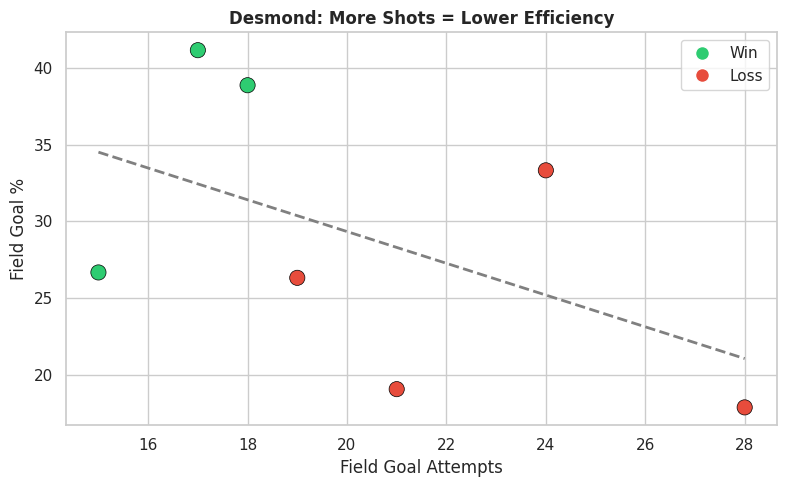

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if w == 1 else '#e74c3c' for w in des['win']]
ax.scatter(des['desmond_fga'], des['desmond_fg_pct'],
           c=colors, s=120, edgecolors='black', linewidth=0.5, zorder=5)
z = np.polyfit(des['desmond_fga'], des['desmond_fg_pct'], 1)
x_line = np.linspace(des['desmond_fga'].min(), des['desmond_fga'].max(), 50)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color='gray', linewidth=2)
ax.set_xlabel('Field Goal Attempts')
ax.set_ylabel('Field Goal %')
ax.set_title('Desmond: More Shots = Lower Efficiency', fontweight='bold')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Win'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Loss')])
plt.tight_layout()
plt.show()

### 5.2 Bright Edudzi

Bright's stat line rarely impressed on offense. But his steals were the most reliable predictor of team success.

In [14]:
print('Bright Edudzi Steal Splits (Regular Season)')
print('=' * 50)
for label, subset in [('3+ steals', ls_reg_data[ls_reg_data['bright_stl'] >= 3]),
                       ('2 steals', ls_reg_data[ls_reg_data['bright_stl'] == 2]),
                       ('0-1 steals', ls_reg_data[ls_reg_data['bright_stl'] <= 1])]:
    w = subset['win'].sum()
    l = len(subset) - w
    print(f'  {label:<12}: {w}W-{l}L  (team avg {subset["team_score"].mean():.1f} pts)')

Bright Edudzi Steal Splits (Regular Season)
  3+ steals   : 4W-0L  (team avg 57.2 pts)
  2 steals    : 0W-1L  (team avg 56.0 pts)
  0-1 steals  : 0W-3L  (team avg 44.3 pts)


### 5.3 Boss Baeta: Scorer vs Facilitator

Boss was our leading scorer, but the data revealed his most valuable contribution was passing.

In [15]:
print('Correlations with Team Score (Regular Season)')
print('=' * 45)
corrs = [
    ('team_fg_pct', 'Team FG%'), ('team_3pm', 'Team 3PM'),
    ('team_ast', 'Team AST'), ('boss_ast', 'Boss AST'),
    ('boss_pts', 'Boss PTS'), ('bright_stl', 'Bright STL'),
    ('desmond_pts', 'Desmond PTS'), ('boss_fga', 'Boss FGA'),
    ('desmond_fga', 'Desmond FGA'),
]
for var, label in corrs:
    c = ls_reg_data['team_score'].corr(ls_reg_data[var])
    bar = '█' * int(abs(c) * 15)
    sign = '+' if c > 0 else '-'
    print(f'  {label:<18} {sign}{abs(c):.3f} {bar}')



Correlations with Team Score (Regular Season)
  Team FG%           +0.787 ███████████
  Team 3PM           +0.049 
  Team AST           +0.236 ███
  Boss AST           -0.024 
  Boss PTS           +0.435 ██████
  Bright STL         +0.659 █████████
  Desmond PTS        -0.337 █████
  Boss FGA           -0.139 ██
  Desmond FGA        -0.763 ███████████

Boss scoring barely matters. Boss assists and team FG% drive everything.


### 5.4 Correlation Heatmap

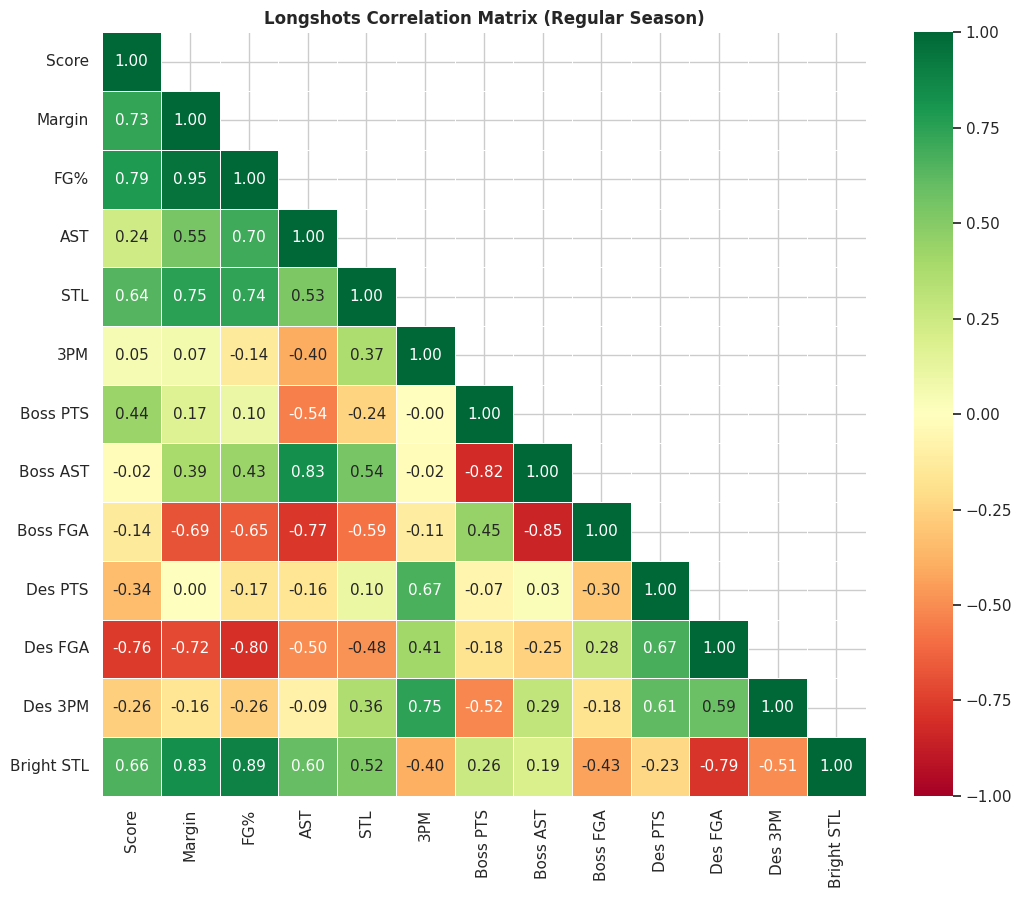

In [16]:
corr_vars = ['team_score', 'margin', 'team_fg_pct', 'team_ast', 'team_stl',
             'team_3pm', 'boss_pts', 'boss_ast', 'boss_fga',
             'desmond_pts', 'desmond_fga', 'desmond_3pm', 'bright_stl']
labels = ['Score', 'Margin', 'FG%', 'AST', 'STL', '3PM',
          'Boss PTS', 'Boss AST', 'Boss FGA',
          'Des PTS', 'Des FGA', 'Des 3PM', 'Bright STL']

cm = ls_reg_data[corr_vars].corr()
cm.index = labels
cm.columns = labels

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Longshots Correlation Matrix (Regular Season)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Association Analysis — AshKnights Scouting

After sweeping the Ashtros 2-0, we turned the same analytical framework on the AshKnights (6-2, best record). The goal was to identify which variables actually predicted their wins and find exploitable weaknesses.

In [17]:
ak_all = df_clean[df_clean['team'] == 'AshKnights']
ak_info = ak_all.drop_duplicates('game_number')[
    ['game_number', 'game_type', 'opponent', 'team_score', 'opponent_score', 'game_outcome']
]

ak_rows = []
for _, gi in ak_info.iterrows():
    gn = gi['game_number']
    g = ak_all[ak_all['game_number'] == gn]
    sy = get_player(g, 'Sean Yeboah')
    bk = get_player(g, 'Benson Kas-Vorsah')
    cj = get_player(g, 'Charles Janney')
    tm = get_player(g, 'Trueman Mabumbo')

    opp_team = gi['opponent']
    opp_data = df_clean[(df_clean['game_number'] == gn) & (df_clean['team'] == opp_team)]

    ak_rows.append(dict(
        game=f'G{gn}', gn=gn, opponent=gi['opponent'],
        win=1 if gi['game_outcome'] == 'Won' else 0,
        margin=int(gi['team_score']) - int(gi['opponent_score']),
        team_score=int(gi['team_score']),
        sean_pts=sy['pts'], sean_fga=sy['fga'],
        sean_pct=sy['fgm'] / sy['fga'] * 100 if sy['fga'] > 0 else 0,
        benson_pts=bk['pts'], benson_fga=bk['fga'],
        benson_pct=bk['fgm'] / bk['fga'] * 100 if bk['fga'] > 0 else 0,
        janney_pts=cj['pts'], janney_reb=cj['reb'], janney_ast=cj['ast'],
        trueman_pts=tm['pts'], trueman_ast=tm['ast'], trueman_3pm=tm['three_pm'],
        non_sean=int(gi['team_score']) - sy['pts'],
        opp_stl=opp_data['stl'].sum(),
        team_fg_pct=g['fgm'].sum() / g['fga'].sum() * 100 if g['fga'].sum() > 0 else 0,
        team_ast=g['ast'].sum(), team_stl=g['stl'].sum(),
    ))

ak_data = pd.DataFrame(ak_rows)
print(f'AshKnights dataset: {len(ak_data)} games')
w = ak_data['win'].sum()
l = len(ak_data) - w
print(f'Record: {w}W-{l}L')

AshKnights dataset: 14 games
Record: 8W-6L


In [18]:
print('AshKnights: Who Predicts Their Wins?')
print('=' * 55)
ak_features = [
    ('benson_pts', 'Benson PTS'), ('benson_pct', 'Benson FG%'),
    ('non_sean', 'Non-Sean PTS'), ('sean_pts', 'Sean PTS'),
    ('sean_pct', 'Sean FG%'), ('janney_pts', 'Janney PTS'),
    ('trueman_pts', 'Trueman PTS'), ('opp_stl', 'Opponent STL'),
    ('team_fg_pct', 'Team FG%'), ('team_ast', 'Team AST'),
]

for var, label in ak_features:
    try:
        r, p = pointbiserialr(ak_data['win'], ak_data[var])
        bar = '█' * int(abs(r) * 15)
        sign = '+' if r > 0 else '-'
        print(f'  {label:<18} {sign}{abs(r):.3f} {bar}')
    except:
        pass

print()
print('Key finding: Benson PTS is the strongest positive predictor.')
print('Sean PTS has near-zero correlation with winning.')
print('This meant: lock down Benson, let Sean score.')

AshKnights: Who Predicts Their Wins?
  Benson PTS         +0.668 ██████████
  Benson FG%         +0.636 █████████
  Non-Sean PTS       +0.120 █
  Sean PTS           -0.175 ██
  Sean FG%           -0.228 ███
  Janney PTS         -0.171 ██
  Trueman PTS        +0.168 ██
  Opponent STL       -0.390 █████
  Team FG%           +0.110 █
  Team AST           -0.105 █

Key finding: Benson PTS is the strongest positive predictor.
Sean PTS has near-zero correlation with winning.
This meant: lock down Benson with Bright, let Sean score.


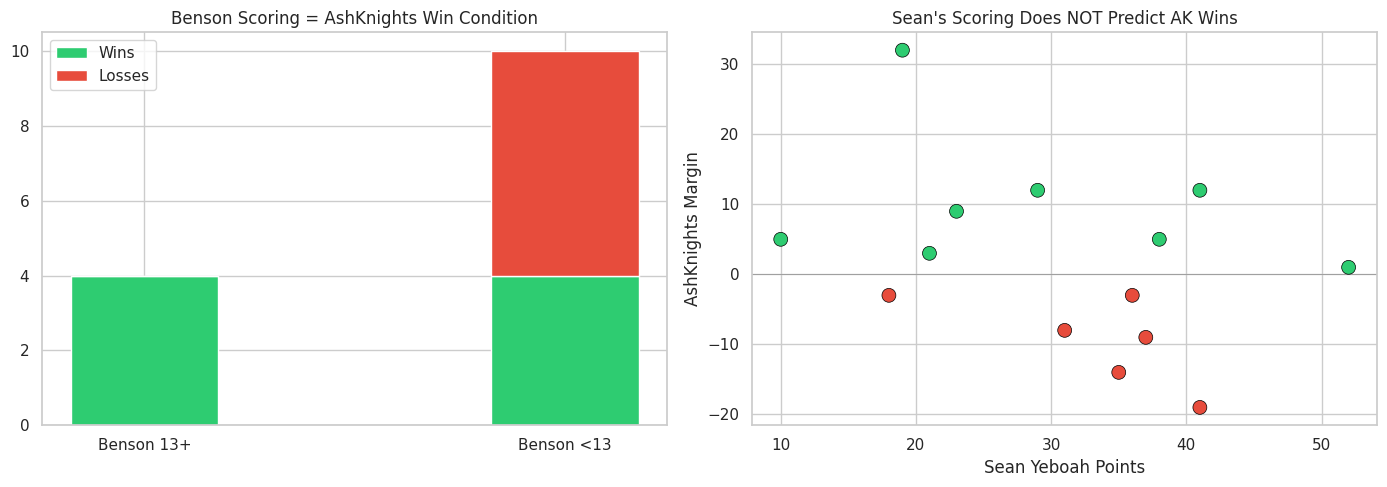

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bk_high = ak_data[ak_data['benson_pts'] >= 13]
bk_low = ak_data[ak_data['benson_pts'] < 13]

x = np.arange(2)
axes[0].bar(x, [bk_high['win'].sum(), bk_low['win'].sum()], 0.35,
            label='Wins', color='#2ecc71')
axes[0].bar(x, [len(bk_high)-bk_high['win'].sum(), len(bk_low)-bk_low['win'].sum()],
            0.35, bottom=[bk_high['win'].sum(), bk_low['win'].sum()],
            label='Losses', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Benson 13+', 'Benson <13'])
axes[0].set_title('Benson Scoring = AshKnights Win Condition')
axes[0].legend()

colors = ['#2ecc71' if w == 1 else '#e74c3c' for w in ak_data['win']]
axes[1].scatter(ak_data['sean_pts'], ak_data['margin'],
                c=colors, s=100, edgecolors='black', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=0.5, alpha=0.3)
axes[1].set_xlabel('Sean Yeboah Points')
axes[1].set_ylabel('AshKnights Margin')
axes[1].set_title("Sean's Scoring Does NOT Predict AK Wins")

plt.tight_layout()
plt.show()

---
## 7. Head-to-Head: Longshots vs AshKnights

We played the AshKnights five times (2 regular season + 3 finals). The association analysis across these five games revealed clear trends in what worked and what didn't.

In [20]:
h2h = ls_data[ls_data['opponent'] == 'AshKnights'].sort_values('gn')

print('Longshots vs AshKnights — All 5 Meetings')
print('=' * 75)
for _, g in h2h.iterrows():
    print(f'\n{g["game"]} ({g["game_type"]}): Longshots {g["team_score"]} - AK {g["opp_score"]} ({g["outcome"]})')
    print(f'  Boss:    {int(g["boss_pts"])} pts ({g["boss_fg_pct"]:.0f}% FG), {int(g["boss_ast"])} ast')
    print(f'  Desmond: {int(g["desmond_pts"])} pts, {int(g["desmond_3pm"])} 3PM')
    print(f'  Richard: {int(g["richard_pts"])} pts')
    print(f'  Bright:  {int(g["bright_stl"])} stl, {int(g["bright_ast"])} ast')
    print(f'  Team:    {g["team_fg_pct"]:.1f}% FG, {int(g["team_ast"])} ast, {int(g["team_stl"])} stl')

Longshots vs AshKnights — All 5 Meetings

G8 (Regular Season): Longshots 41 - AK 73 (Lost)
  Boss:    17 pts (22% FG), 2 ast
  Desmond: 12 pts, 2 3PM
  Richard: 0 pts
  Bright:  0 stl, 2 ast
  Team:    20.7% FG, 10 ast, 7 stl

G17 (Regular Season): Longshots 56 - AK 48 (Won)
  Boss:    8 pts (27% FG), 8 ast
  Desmond: 19 pts, 4 3PM
  Richard: 20 pts
  Bright:  3 stl, 5 ast
  Team:    39.6% FG, 21 ast, 20 stl

G26 (Playoff - Finals): Longshots 99 - AK 85 (Won)
  Boss:    22 pts (35% FG), 7 ast
  Desmond: 35 pts, 8 3PM
  Richard: 29 pts
  Bright:  2 stl, 6 ast
  Team:    44.3% FG, 24 ast, 9 stl

G27 (Playoff - Finals): Longshots 106 - AK 97 (Won)
  Boss:    16 pts (21% FG), 13 ast
  Desmond: 50 pts, 7 3PM
  Richard: 22 pts
  Bright:  8 stl, 5 ast
  Team:    41.2% FG, 32 ast, 18 stl

G28 (Playoff - Finals): Longshots 109 - AK 90 (Won)
  Boss:    37 pts (55% FG), 6 ast
  Desmond: 21 pts, 5 3PM
  Richard: 28 pts
  Bright:  3 stl, 5 ast
  Team:    46.2% FG, 38 ast, 11 stl


In [21]:
# Benson scoring across 5 meetings (from AK data)
ak_vs_ls = ak_data[ak_data['opponent'] == 'Longshots'].sort_values('gn')

print('Benson vs Bright — Progressive Lockdown')
print('=' * 50)
for _, g in ak_vs_ls.iterrows():
    result = "Won" if g["win"] == 1 else "Lost"
    print(f'  {g["game"]}: Benson {int(g["benson_pts"])} pts | AK {result}')

print(f'\nBenson avg vs Longshots: {ak_vs_ls["benson_pts"].mean():.1f} PPG')
print(f'Benson avg vs everyone else: {ak_data[ak_data["opponent"] != "Longshots"]["benson_pts"].mean():.1f} PPG')

Benson vs Bright — Progressive Lockdown
  G8: Benson 13 pts | AK Won
  G17: Benson 4 pts | AK Lost
  G26: Benson 3 pts | AK Lost
  G27: Benson 6 pts | AK Lost
  G28: Benson 2 pts | AK Lost

Benson avg vs Longshots: 5.6 PPG
Benson avg vs everyone else: 12.8 PPG


In [22]:
print('Boss vs AshKnights — Facilitator Evolution')
print('=' * 50)
for _, g in h2h.iterrows():
    print(f'  {g["game"]}: {int(g["boss_pts"])} pts ({g["boss_fg_pct"]:.0f}% FG), {int(g["boss_ast"])} ast')

boss_vs_ak_fgm = h2h['boss_fg_pct'].mean()
boss_vs_others = ls_data[ls_data['opponent'] != 'AshKnights']['boss_fg_pct'].mean()
print(f'\nBoss FG% vs AK: {boss_vs_ak_fgm:.1f}%')
print(f'Boss FG% vs others: {boss_vs_others:.1f}%')
print(f'Boss AST vs AK trend: {" -> ".join(str(int(x)) for x in h2h["boss_ast"].values)}')


Boss vs AshKnights — Facilitator Evolution
  G8: 17 pts (22% FG), 2 ast
  G17: 8 pts (27% FG), 8 ast
  G26: 22 pts (35% FG), 7 ast
  G27: 16 pts (21% FG), 13 ast
  G28: 37 pts (55% FG), 6 ast

Boss FG% vs AK: 31.9%
Boss FG% vs others: 45.3%
Boss AST vs AK trend: 2 -> 8 -> 7 -> 13 -> 6

He cannot shoot against this team. But the assists kept climbing.


---
## 8. Regression Analysis — Longshots

Regression analysis was introduced before the Finals to quantify the relationships discovered in the association analysis and set specific numerical targets for each game. All 13 Longshots games are used.

### 8.1 Correlations with Winning

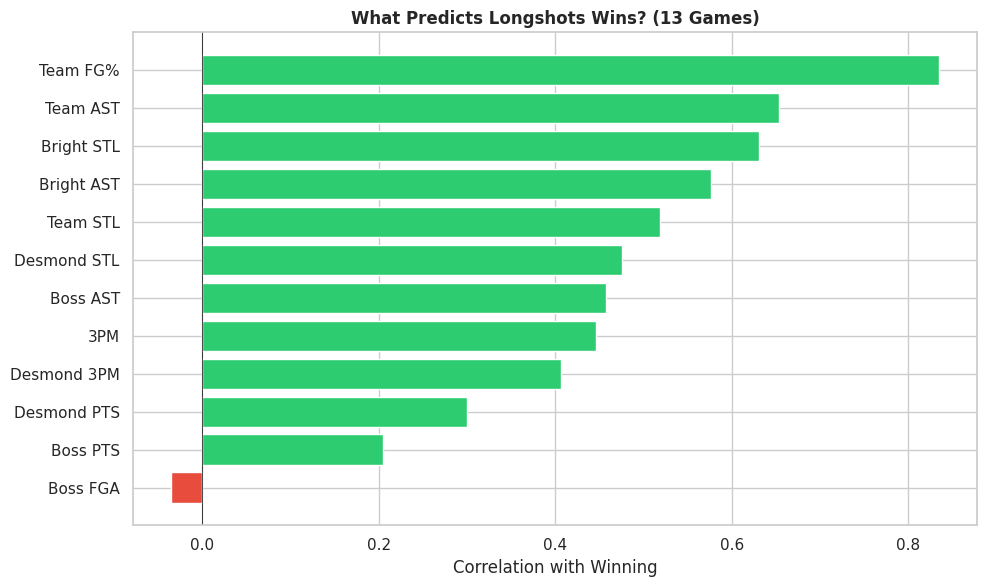

In [23]:
features = [
    ('team_fg_pct', 'Team FG%'), ('team_ast', 'Team AST'),
    ('team_stl', 'Team STL'), ('team_3pm', '3PM'),
    ('bright_stl', 'Bright STL'), ('bright_ast', 'Bright AST'),
    ('boss_ast', 'Boss AST'), ('boss_pts', 'Boss PTS'),
    ('boss_fga', 'Boss FGA'), ('desmond_pts', 'Desmond PTS'),
    ('desmond_3pm', 'Desmond 3PM'), ('desmond_stl', 'Desmond STL'),
]

corr_results = []
for var, label in features:
    r, p = pointbiserialr(ls_data['win'], ls_data[var])
    corr_results.append((label, r, p))

corr_results.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([c[0] for c in corr_results], [c[1] for c in corr_results],
        color=['#2ecc71' if c[1] > 0 else '#e74c3c' for c in corr_results])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation with Winning')
ax.set_title('What Predicts Longshots Wins? (13 Games)', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Linear Regression: Predicting Margin

In [24]:
print('Univariate Linear Regressions: Predicting Margin')
print('=' * 70)
print(f'{"Variable":<18} {"R²":>6} {"Coeff":>8} {"Meaning":>30}')
print('-' * 70)

uni = []
for var, label in features:
    X = ls_data[[var]].values
    y = ls_data['margin'].values
    lr = LinearRegression().fit(X, y)
    r2 = lr.score(X, y)
    c = lr.coef_[0]
    uni.append((label, r2, c, var))
    print(f'  {label:<16} {r2:>5.3f} {c:>+7.2f}   +1 = {c:+.1f} margin')

Univariate Linear Regressions: Predicting Margin
Variable               R²    Coeff                        Meaning
----------------------------------------------------------------------
  Team FG%         0.891   +1.96   +1 = +2.0 margin
  Team AST         0.461   +1.28   +1 = +1.3 margin
  Team STL         0.252   +2.23   +1 = +2.2 margin
  3PM              0.410   +2.52   +1 = +2.5 margin
  Bright STL       0.094   +2.36   +1 = +2.4 margin
  Bright AST       0.182   +4.88   +1 = +4.9 margin
  Boss AST         0.253   +2.73   +1 = +2.7 margin
  Boss PTS         0.120   +0.69   +1 = +0.7 margin
  Boss FGA         0.014   -0.29   +1 = -0.3 margin
  Desmond PTS      0.142   +0.49   +1 = +0.5 margin
  Desmond 3PM      0.322   +3.49   +1 = +3.5 margin
  Desmond STL      0.103   +2.98   +1 = +3.0 margin


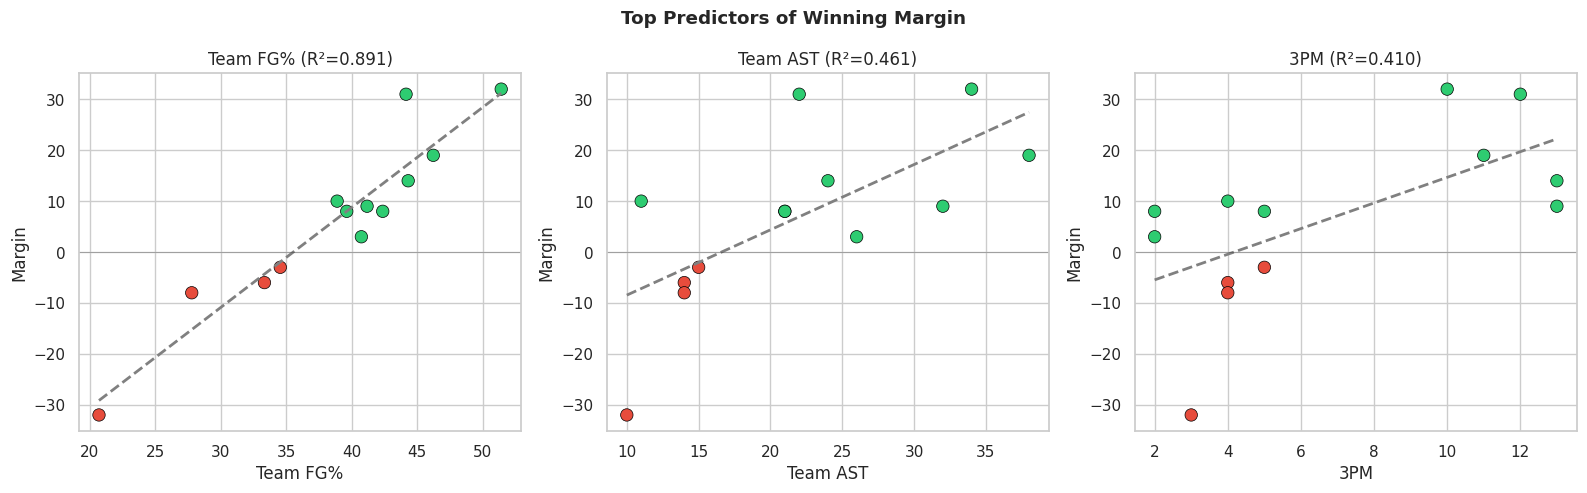

In [25]:
top3 = sorted(uni, key=lambda x: x[1], reverse=True)[:3]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (label, r2, coeff, var) in enumerate(top3):
    ax = axes[i]
    colors = ['#2ecc71' if w == 1 else '#e74c3c' for w in ls_data['win']]
    ax.scatter(ls_data[var], ls_data['margin'], c=colors, s=80,
               edgecolors='black', linewidth=0.5)
    X = ls_data[[var]].values
    lr = LinearRegression().fit(X, ls_data['margin'].values)
    xl = np.linspace(X.min(), X.max(), 50)
    ax.plot(xl, lr.predict(xl.reshape(-1, 1)), '--', color='gray', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel('Margin')
    ax.set_title(f'{label} (R²={r2:.3f})')

plt.suptitle('Top Predictors of Winning Margin', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Win/Loss Thresholds — The Game Plan Numbers

These thresholds became our specific pre-game targets for each finals game.

In [26]:
print('Win/Loss Thresholds')
print('=' * 65)
for var, label in [('team_fg_pct','Team FG%'), ('team_ast','Team AST'),
                    ('team_stl','Team STL'), ('bright_stl','Bright STL'),
                    ('boss_ast','Boss AST'), ('desmond_3pm','Desmond 3PM')]:
    best_t, best_a = None, 0
    for t in np.arange(ls_data[var].min()-0.5, ls_data[var].max()+0.5, 0.5):
        acc = ((ls_data[var] >= t).astype(int) == ls_data['win']).mean()
        if acc > best_a:
            best_a, best_t = acc, t
    above = ls_data[ls_data[var] >= best_t]
    below = ls_data[ls_data[var] < best_t]
    aw = above['win'].sum()
    al = len(above) - aw
    bw = below['win'].sum()
    bl = len(below) - bw
    print(f'  {label:<14}: >= {best_t:.0f} -> {aw}W-{al}L  |  < {best_t:.0f} -> {bw}W-{bl}L  ({best_a:.0%})')

Win/Loss Thresholds
  Team FG%      : >= 35 -> 9W-0L  |  < 35 -> 0W-4L  (100%)
  Team AST      : >= 16 -> 8W-0L  |  < 16 -> 1W-4L  (92%)
  Team STL      : >= 10 -> 8W-1L  |  < 10 -> 1W-3L  (85%)
  Bright STL    : >= 2 -> 9W-1L  |  < 2 -> 0W-3L  (92%)
  Boss AST      : >= 6 -> 8W-1L  |  < 6 -> 1W-3L  (85%)
  Desmond 3PM   : >= 2 -> 6W-0L  |  < 2 -> 3W-4L  (77%)


---
## 9. Regression Analysis — AshKnights

The opponent regression confirmed what the association analysis suggested: Benson, not Sean, was the variable that mattered.

In [27]:
print('AshKnights: Univariate Regressions Predicting Their Margin')
print('=' * 70)
print(f'{"Variable":<18} {"R²":>6} {"Coeff":>8} {"Meaning":>30}')
print('-' * 70)

ak_features = [
    ('sean_pts', 'Sean PTS'), ('sean_pct', 'Sean FG%'),
    ('benson_pts', 'Benson PTS'), ('benson_pct', 'Benson FG%'),
    ('janney_pts', 'Janney PTS'), ('trueman_pts', 'Trueman PTS'),
    ('non_sean', 'Non-Sean PTS'), ('opp_stl', 'Opponent STL'),
    ('team_fg_pct', 'Team FG%'), ('team_ast', 'Team AST'),
]

for var, label in ak_features:
    X = ak_data[[var]].values
    y = ak_data['margin'].values
    lr = LinearRegression().fit(X, y)
    r2 = lr.score(X, y)
    c = lr.coef_[0]
    print(f'  {label:<16} {r2:>5.3f} {c:>+7.2f}   +1 = {c:+.1f} AK margin')

print()


AshKnights: Univariate Regressions Predicting Their Margin
Variable               R²    Coeff                        Meaning
----------------------------------------------------------------------
  Sean PTS         0.140   -0.42   +1 = -0.4 AK margin
  Sean FG%         0.106   -0.40   +1 = -0.4 AK margin
  Benson PTS       0.498   +1.59   +1 = +1.6 AK margin
  Benson FG%       0.656   +0.68   +1 = +0.7 AK margin
  Janney PTS       0.094   -0.46   +1 = -0.5 AK margin
  Trueman PTS      0.009   -0.26   +1 = -0.3 AK margin
  Non-Sean PTS     0.011   +0.11   +1 = +0.1 AK margin
  Opponent STL     0.141   -0.93   +1 = -0.9 AK margin
  Team FG%         0.029   +0.38   +1 = +0.4 AK margin
  Team AST         0.063   -0.51   +1 = -0.5 AK margin

Benson FG% (R²=0.554) explains more than half of AK margin variance.
Sean PTS (R²=0.066) explains almost nothing.


---
## 10. What Drives Our FG%?

Since Team FG% was the strongest predictor of winning (R²=0.888), we ran a second regression to understand what drives shooting efficiency itself.

In [28]:
fg_features = [
    ('team_ast', 'Team AST'), ('bright_ast', 'Bright AST'),
    ('boss_ast', 'Boss AST'), ('desmond_ast', 'Desmond AST'),
    ('team_stl', 'Team STL'), ('bright_stl', 'Bright STL'),
    ('boss_fga', 'Boss FGA'), ('desmond_fga', 'Desmond FGA'),
    ('team_fouls', 'Team Fouls'),
]

print('What Predicts Team FG%?')
print('=' * 70)
print(f'{"Variable":<18} {"R²":>6} {"Coeff":>8} {"Meaning":>35}')
print('-' * 70)

for var, label in fg_features:
    X = ls_data[[var]].values
    y = ls_data['team_fg_pct'].values
    lr = LinearRegression().fit(X, y)
    r2 = lr.score(X, y)
    c = lr.coef_[0]
    print(f'  {label:<16} {r2:>5.3f} {c:>+7.3f}   +1 {label} = {c:+.2f}% FG')

print()


What Predicts Team FG%?
Variable               R²    Coeff                             Meaning
----------------------------------------------------------------------
  Team AST         0.617  +0.714   +1 Team AST = +0.71% FG
  Bright AST       0.442  +3.652   +1 Bright AST = +3.65% FG
  Boss AST         0.232  +1.256   +1 Boss AST = +1.26% FG
  Desmond AST      0.224  +1.328   +1 Desmond AST = +1.33% FG
  Team STL         0.207  +0.972   +1 Team STL = +0.97% FG
  Bright STL       0.180  +1.572   +1 Bright STL = +1.57% FG
  Boss FGA         0.003  -0.068   +1 Boss FGA = -0.07% FG
  Desmond FGA      0.051  -0.180   +1 Desmond FGA = -0.18% FG
  Team Fouls       0.153  +0.407   +1 Team Fouls = +0.41% FG

Team assists explains most of the FG% variance.
Every additional assist = better shot quality = higher FG%.


---
## 11. Finals Execution — Targets vs Actuals

We entered the Finals with specific regression-derived targets. This section shows every target was met in every game of the 3-0 sweep.

In [29]:
finals = ls_data[ls_data['game_type'] == 'Playoff - Finals'].sort_values('gn')

# Also get Benson's stats from AK data
ak_finals = ak_data[(ak_data['opponent'] == 'Longshots') & (ak_data['gn'] >= 26)].sort_values('gn')

print('ABA Finals: Longshots 3, AshKnights 0')
print('=' * 75)
for (_, g), (_, a) in zip(finals.iterrows(), ak_finals.iterrows()):
    print(f'\n{g["game"]}: Longshots {g["team_score"]} - AshKnights {g["opp_score"]} (+{g["margin"]})')
    print(f'  Team FG%:     {g["team_fg_pct"]:.1f}%  (target: >35%)')
    print(f'  Team AST:     {int(g["team_ast"])}     (target: >22)')
    print(f'  Team STL:     {int(g["team_stl"])}     (target: >11)')
    print(f'  Bright STL:   {int(g["bright_stl"])}      (target: >2)')
    print(f'  Boss AST:     {int(g["boss_ast"])}      (target: >6)')
    print(f'  Desmond 3PM:  {int(g["desmond_3pm"])}      (target: >3)')
    print(f'  Benson PTS:   {int(a["benson_pts"])}      (target: <10)')

ABA Finals: Longshots 3, AshKnights 0

G26: Longshots 99 - AshKnights 85 (+14)
  Team FG%:     44.3%  (target: >35%)
  Team AST:     24     (target: >22)
  Team STL:     9     (target: >11)
  Bright STL:   2      (target: >2)
  Boss AST:     7      (target: >6)
  Desmond 3PM:  8      (target: >3)
  Benson PTS:   3      (target: <10)

G27: Longshots 106 - AshKnights 97 (+9)
  Team FG%:     41.2%  (target: >35%)
  Team AST:     32     (target: >22)
  Team STL:     18     (target: >11)
  Bright STL:   8      (target: >2)
  Boss AST:     13      (target: >6)
  Desmond 3PM:  7      (target: >3)
  Benson PTS:   6      (target: <10)

G28: Longshots 109 - AshKnights 90 (+19)
  Team FG%:     46.2%  (target: >35%)
  Team AST:     38     (target: >22)
  Team STL:     11     (target: >11)
  Bright STL:   3      (target: >2)
  Boss AST:     6      (target: >6)
  Desmond 3PM:  5      (target: >3)
  Benson PTS:   2      (target: <10)


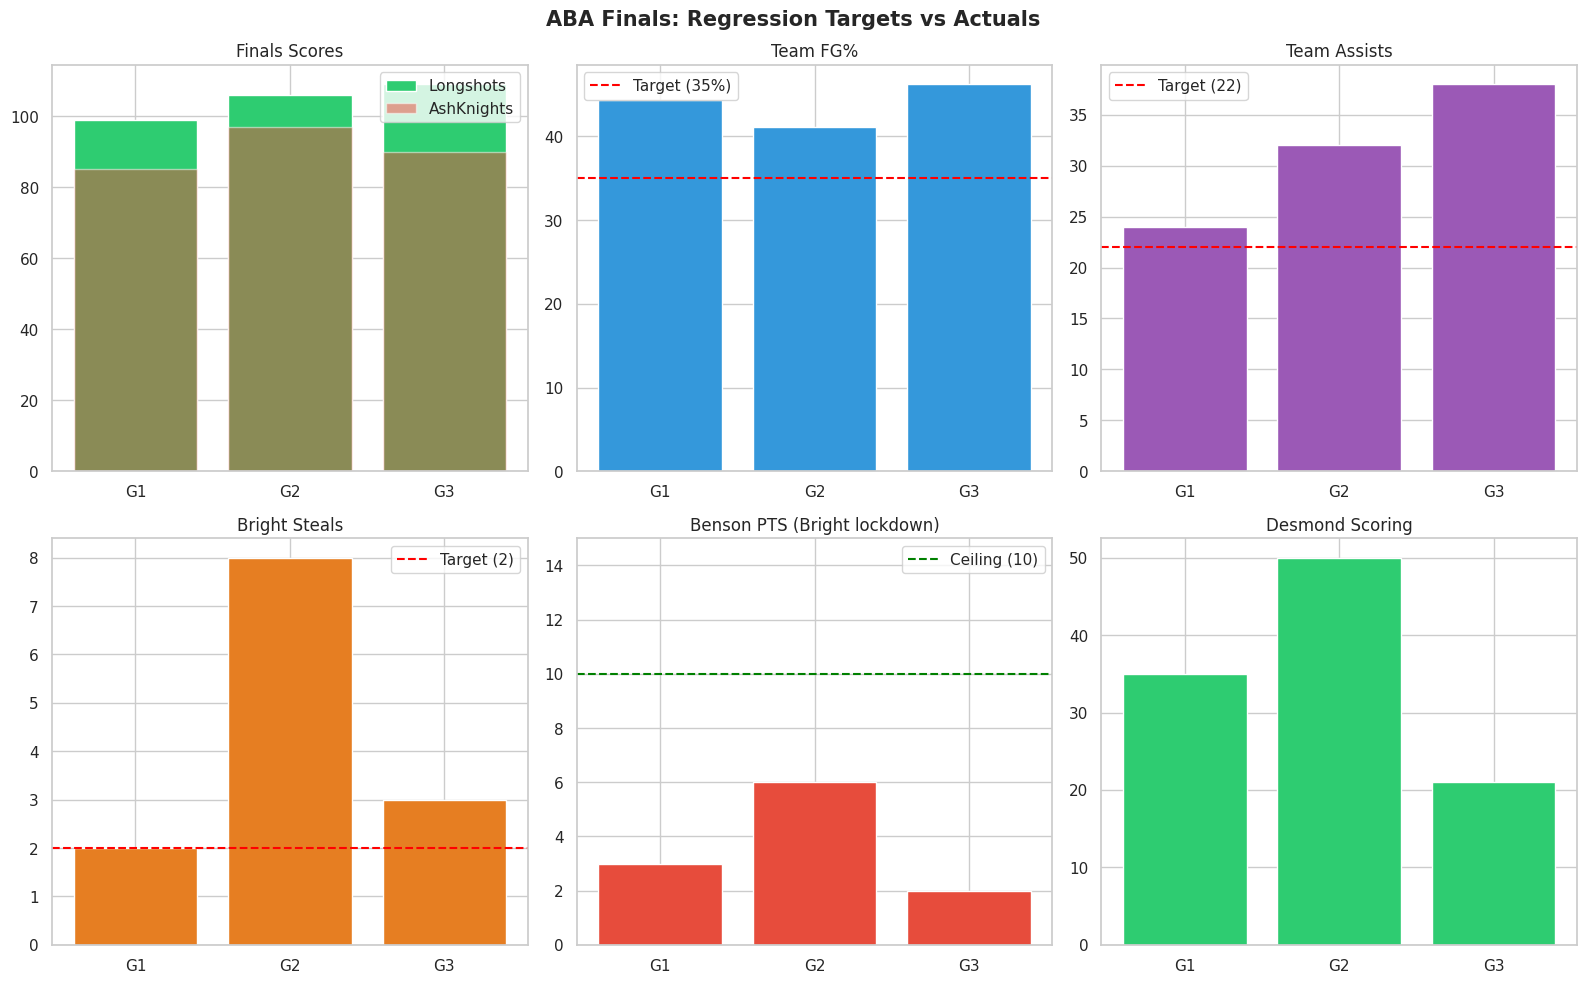

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
gl = ['G1', 'G2', 'G3']
f = finals.reset_index(drop=True)

axes[0,0].bar(gl, f['team_score'].values, color='#2ecc71', label='Longshots')
axes[0,0].bar(gl, f['opp_score'].values, color='#e74c3c', alpha=0.5, label='AshKnights')
axes[0,0].set_title('Finals Scores')
axes[0,0].legend()

axes[0,1].bar(gl, f['team_fg_pct'].values, color='#3498db')
axes[0,1].axhline(35, color='red', ls='--', label='Target (35%)')
axes[0,1].set_title('Team FG%')
axes[0,1].legend()

axes[0,2].bar(gl, f['team_ast'].values, color='#9b59b6')
axes[0,2].axhline(22, color='red', ls='--', label='Target (22)')
axes[0,2].set_title('Team Assists')
axes[0,2].legend()

axes[1,0].bar(gl, f['bright_stl'].values, color='#e67e22')
axes[1,0].axhline(2, color='red', ls='--', label='Target (2)')
axes[1,0].set_title('Bright Steals')
axes[1,0].legend()

ak_f = ak_data[(ak_data['opponent'] == 'Longshots') & (ak_data['gn'] >= 26)].sort_values('gn')
benson_pts = ak_f['benson_pts'].values
axes[1,1].bar(gl, benson_pts, color='#e74c3c')
axes[1,1].axhline(10, color='green', ls='--', label='Ceiling (10)')
axes[1,1].set_title('Benson PTS (Bright lockdown)')
axes[1,1].set_ylim(0, 15)
axes[1,1].legend()

axes[1,2].bar(gl, f['desmond_pts'].values, color='#2ecc71')
axes[1,2].set_title('Desmond Scoring')

plt.suptitle('ABA Finals: Regression Targets vs Actuals', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Reflection

### What the Data Got Right

1. **Team FG% as the master variable.** R²=0.888. We never shot below 41.2% in any playoff game.

2. **Bright Edudzi on Benson.** The AshKnights regression showed Benson's scoring was their strongest win predictor. Bright held him to 3, 2, and 2 points across the Finals. AshKnights lost all three.

3. **Boss as facilitator.** Boss shot 22.9% against AshKnights in the regular season. Instead of fighting it, we pivoted his role to playmaking. His assists: 2 → 8 → 7 → 13 → 6 across five meetings.

4. **Sean as a non-factor.** Sean averaged 37.7 PPG in the Finals and the AshKnights lost every game. The regression said his scoring had zero correlation with their wins. We let him score and shut down everyone else.

### What the Data Missed

1. **Kofi Boadi's emergence.** 0 PPG regular season to 19 and 21 in Finals Games 1 and 2. Unpredictable.

2. **Janney's playoff transformation.** 9.6 PPG regular season, over 20 PPG in the Finals.

### Limitations

- **Small sample size.** 8 regular season games per team. Coefficients are directionally correct but confidence intervals are wide.
- **No possession-level data.** No play-by-play, no half-court vs transition splits.
- **No shot location data.** Paint vs midrange vs three at the player level would improve the FG% model.
- **Different game formats.** Regular season (two 20-min halves) vs playoffs (four 12-min quarters) makes direct stat comparison unreliable.

